# Pedestrian Graph "Plan de la Limace"

In [1]:
import os
import sys

import matplotlib.pyplot as plt

# Ajout dans la variable PATH du système du chemin où est installée la librairie tracklib
module_path = os.path.abspath(os.path.join('../../../../tracklib'))
if module_path not in sys.path:
    sys.path.append(module_path)
# Alias pour tracklib
import tracklib as tkl

# Ajout dans la variable PATH du système du chemin où est installée la librairie footprint2graph
module_path = os.path.abspath(os.path.join('../../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import matplotlib.pyplot as plt
import os
import time

from footprint2graph import run_iteration
from footprint2graph import read_config

from footprint2graph.util.Outdoorvision import load_raw_tracks_split

## Chargement des paramètres

In [3]:
print ('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
print ('`````````````````````````````````````````````````````````````````````')
print ('             Generate a footprint graph                              ')
print ('                      from hiking trajectories                       ')
print ('                      in the Bauges, summer 2024.                    ')
print ('’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’')
print ('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
print ('')


""" ======================================================================= """
"""     Load parameters                                                     """
"""                                                                         """

config_path = r'/home/md_vandamme/7_LIB/footprint2graph/data/config_bauges.yml'
config = read_config(config_path)


print('Paramètres relevés dans la configuration: ')
print ('Résultats enregistrés dans le répertoire: ', config['output']['RESULT_PATH'])

NBITER = int(config['graph_construction']['NUM_ITERATIONS'])
print ('Number of iterations: ', NBITER)

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
`````````````````````````````````````````````````````````````````````
             Generate a footprint graph                              
                      from hiking trajectories                       
                      in the Bauges, summer 2024.                    
’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

Paramètres relevés dans la configuration: 
Résultats enregistrés dans le répertoire:  /home/md_vandamme/4_RESEAU/ZTEMPZ1/
Number of iterations:  2


## Chargement des données

Les données proviennent de la plateforme Outdoorvision. Après avoir été formatées au format CSV, elles sont chargées dans une collection qui servira d'entrée au pipeline.

In [4]:
""" ======================================================================= """
"""     Chargement de la collection de traces                               """
"""                                                                         """

# chemin où sont stockés les traces Outdoorvision:
tracespathsource = r'/home/md_vandamme/5_GPS/OV/BAUGES/walk/'

# Paramètre : Coordonnées de la zone d'étude sur laquelle on construit le réseau
#                           Polygone sous la forme d'un tableau de X et de Y
# traces de la zone 1 (3km x 3km)
X = [950987, 951409, 950696, 949467, 947934, 948545, 950987]
Y = [6513197, 6512091, 6511113, 6510719, 6511949, 6512621, 6513197]

fmt = tkl.TrackFormat({'ext': 'CSV',
                       'srid': 'ENU',
                       'id_E': 1, 'id_N': 0, 'id_U': 3, 'id_T': 2,
                       'time_fmt': '2D/2M/4Y 2h:2m:2s',
                       'separator': ';',
                       'header': 0,
                       'cmt': '#',
                       'read_all': True})
collection = load_raw_tracks_split(config['output']['RESULT_PATH'],
                                   tracespathsource, fmt, X, Y)

Loading and split outdoorvision track data...
Reading track data...
     Number files to load:  4145
Starting split ...
     500 / 4145
     1000 / 4145
     1500 / 4145
     2000 / 4145
     2500 / 4145
     3000 / 4145
     3500 / 4145
     4000 / 4145
     Number of tracks after split: 832


## Lancement du pipeline

In [5]:
for idx in range(0, NBITER):
    iteration_index = int(idx) + 1

    # run pipeline for the ith iteration
    run_iteration(iteration_index, config, collection)

print ('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
print ('`````````````````````````````````````````````````````````````````````')
print ('                           FIN                                       ')
print ('’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’')
print ('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')

-----------------------------------------------------------------
-----------------------------------------------------------------
              ITERATION  1
-----------------------------------------------------------------
-----------------------------------------------------------------
Starting segmentation and resampling...
Starting segmentation ...
     500 / 832
    Number of tracks after segmentation: 1171
Finished saving segmented tracks.
Starting resampling ...
    Number of tracks to resample:  1171
    Number of tracks after resampling: 1171
    Number of tracks after resampling: 1171
Finished saving resampled tracks.
Stage 1 finished: segmentation and resampling.
Starting rasterization and vectorization (iteration 1) 

    Loading tracks from :  resample_grid
    Number of tracks to load:  1171
    Building high-resolution geometry density grid G1 :  2 m ...
    Building low-resolution contextual density grid G2 :  30 m ...
    Assigning track points to the G1 and G2 grids

100% (279 of 279) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (279 of 279) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (406 of 406) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (358 of 358) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (211 of 211) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1204 of 1204) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (3195 of 3195) |####################| Elapsed Time: 0:00:00 Time:  0:00:00

    Execution time (seconds): 1.4162557125091553
    Road surface smoothing completed.
    Starting centerline computation ...



100% (3191 of 3191) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (21702 of 21702) |##################| Elapsed Time: 0:00:00 Time:  0:00:000000


    Execution time (seconds): 3.323672294616699
    Centerline computed.
Stage 2 completed: rasterization and vectorization.
Starting topology creation for the network
    Number of edges in the skeleton: 5058
    Finished loaded skeleton.
    /home/md_vandamme/4_RESEAU/ZTEMPZ1/network/tmp_in.csv not exists
    /home/md_vandamme/4_RESEAU/ZTEMPZ1/network/tmp_out.csv not exists


...

    Finished simplification of the skeleton.
Building [100 x 82] spatial index...
    Number of edges in the skeleton (after snapping): 60
    Edge count difference after snapping :  0
    Number of edges in the simplified skeleton: 55
    Number of nodes: 79
     Shortest edges limit :  50
    Number of edges in the skeleton (after removing the shortest edges): 1
    Conflation cannot be performed for node  19 ; the three incident edges are too long: 19 52 31
    Edge count after conflation: 28
Stage 3 completed: adding topology to the skeleton.
Starting map-matching, aggregation, and conflation of GNSS trajectories.
    Loading network (2) ...
        Number of edges =  28
        Number of nodes =  51
        Total segment length of the network =  2359.038212864578
    Loading collection of tracks ...


100% (51 of 51) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


        Number of tracks: 1605
        Execution time (seconds): 3.1952219009399414
    Starting map-matching ...
        Index spatial :  [100 x 82] spatial index centered on [950195.6342437908; 6511752.969261601]
Map-matching preparation...
        Parameter search_radius:  25
        Map-matching ended.
        Execution time (seconds): 23.751001119613647
        Prepare map-matching results for candidate segment generation
    Number of map-matched points = 103337 (46.87 %)
    Map-matching results restructuring completed.
        Map-matching results exported.
Starting construction of candidate trajectory segments for each topology edge ...
    6  candidates for edge 70
    15  candidates for edge 63
    3  candidates for edge 68
    9  candidates for edge 62
    46  candidates for edge 60
    6  candidates for edge 35
    6  candidates for edge 71
    10  candidates for edge 66
    11  candidates for edge 74
    6  candidates for edge 64
    19  candidates for edge 44
    15  can

100% (53 of 53) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


Size of collection In  :  26
Size of collection In+1:  27
Size of collection In+In+1:  53
Building [100 x 74] spatial index...
Size of collection In+In+1 avec intersection:  55
Size of collection In+In+1 avec intersection et raccordement:  82
Size of reseau de mobilité:  82


## On affiche le résultat

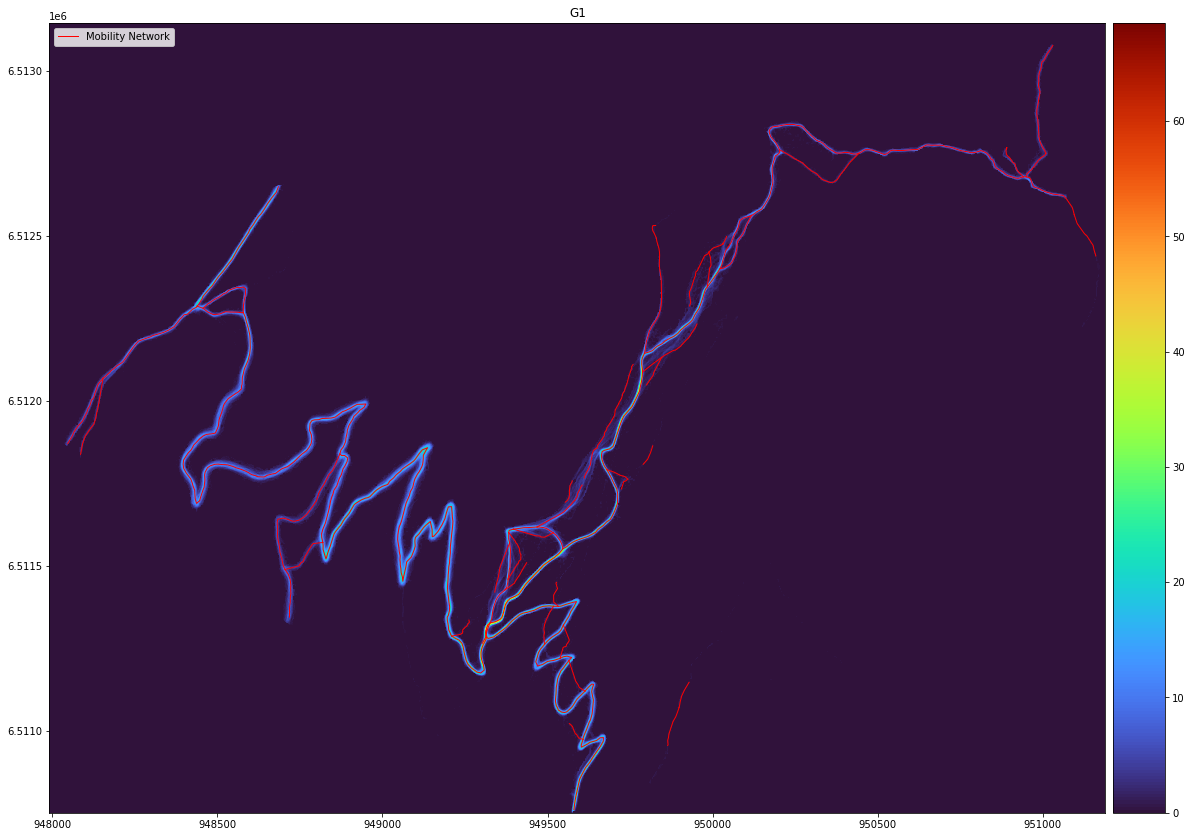

In [4]:
from footprint2graph.util.PlotRes import plotResultatFinal

plotResultatFinal(config['output']['RESULT_PATH'])